# Credit Default Risk Predictor
**Author:** Paula Rezzonico
**Dataset:** Give Me Some Credit — 150,000 borrowers
**Goal:** Predict probability of loan default with a tuned, explainable, stress-tested ML model

---

## Table of Contents
1. **Phase 1** — EDA & Missing Data
2. **Phase 2** — K-Means Borrower Segmentation
3. **Phase 3** — Logistic Regression with Regularization
4. **Phase 4** — Model Progression & Bias-Variance *(incl. MLP neural network)*
5. **Phase 5** — Evaluation & Threshold Tuning
6. **Phase 6** — Cross-Validation & Hyperparameter Tuning
7. **Phase 7** — Model Evaluation Visuals *(confusion matrix, ROC, feature importance)*
8. **Phase 8** — Explainability with SHAP
9. **Phase 9** — Local Explanations with LIME
10. **Phase 10** — Macroeconomic Stress Testing
11. **Phase 11** — Productionization & Model Card

## Phase 1 — Exploratory Data Analysis
Load the data, check for missing values, and run hypothesis tests comparing defaulters vs non-defaulters.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                              precision_score, recall_score, f1_score)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '/Users/paularezzonico/Desktop/credit-default-risk/data/cs-training.csv'
df = pd.read_csv(DATA_PATH, index_col=0)
print("Shape:", df.shape)
print("\nClass balance:")
print(df['SeriousDlqin2yrs'].value_counts())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (150000, 11)

Class balance:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Missing values:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


Missing values after imputation: 0


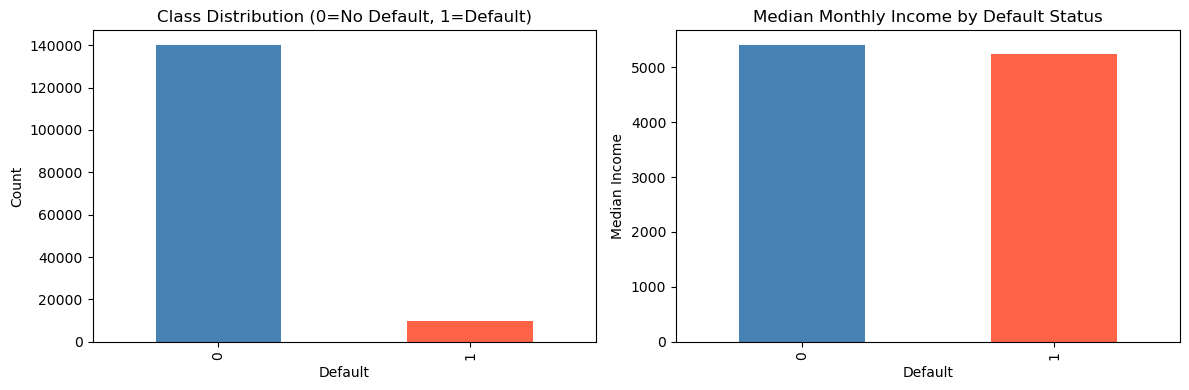

In [10]:
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)
print("Missing values after imputation:", df.isnull().sum().sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Class Distribution (0=No Default, 1=Default)')
axes[0].set_xlabel('Default')
axes[0].set_ylabel('Count')
df.groupby('SeriousDlqin2yrs')['MonthlyIncome'].median().plot(kind='bar', ax=axes[1], color=['steelblue','tomato'])
axes[1].set_title('Median Monthly Income by Default Status')
axes[1].set_xlabel('Default')
axes[1].set_ylabel('Median Income')
plt.tight_layout()
plt.show()


In [11]:
features_to_test = ['RevolvingUtilizationOfUnsecuredLines', 'age',
                    'MonthlyIncome', 'DebtRatio', 'NumberOfTimes90DaysLate']

print(f"{'Feature':<45} {'T-stat':>10} {'P-value':>12} {'Significant':>12}")
print("-" * 82)
for feat in features_to_test:
    group0 = df[df['SeriousDlqin2yrs'] == 0][feat]
    group1 = df[df['SeriousDlqin2yrs'] == 1][feat]
    t_stat, p_val = stats.ttest_ind(group0, group1)
    sig = "YES ***" if p_val < 0.05 else "no"
    print(f"{feat:<45} {t_stat:>10.2f} {p_val:>12.4f} {sig:>12}")


Feature                                           T-stat      P-value  Significant
----------------------------------------------------------------------------------
RevolvingUtilizationOfUnsecuredLines                0.70       0.4854           no
age                                                44.99       0.0000      YES ***
MonthlyIncome                                       6.64       0.0000      YES ***
DebtRatio                                           2.94       0.0032      YES ***
NumberOfTimes90DaysLate                           -45.70       0.0000      YES ***


## Phase 2 — Borrower Segmentation (K-Means Clustering)
Cluster borrowers into risk segments. The cluster label becomes an engineered feature for downstream models.


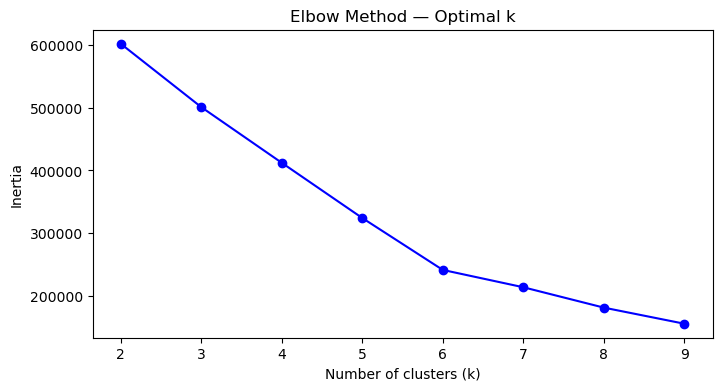

In [13]:
cluster_features = ['RevolvingUtilizationOfUnsecuredLines', 'age',
                    'MonthlyIncome', 'DebtRatio', 'NumberOfTimes90DaysLate']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 10), inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k')
plt.show()

         count  default_rate  avg_age  avg_income  avg_late
cluster                                                    
0        70300         0.039   65.177    6867.060     0.053
1        79391         0.090   40.952    6028.201     0.124
2          269         0.546   34.245    3835.896    97.963
3           40         0.050   47.550    9929.000     0.025


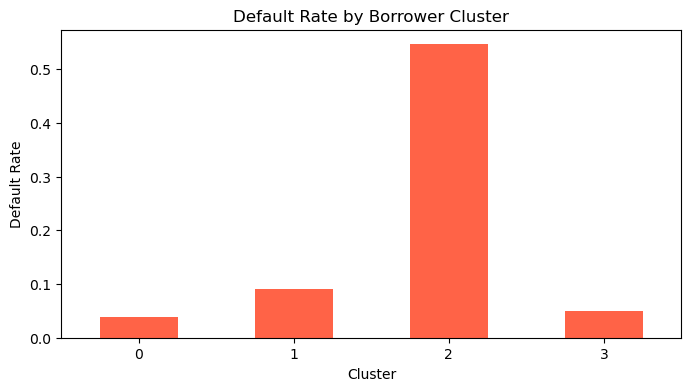

In [14]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

cluster_summary = df.groupby('cluster').agg(
    count=('SeriousDlqin2yrs', 'count'),
    default_rate=('SeriousDlqin2yrs', 'mean'),
    avg_age=('age', 'mean'),
    avg_income=('MonthlyIncome', 'mean'),
    avg_late=('NumberOfTimes90DaysLate', 'mean')
).round(3)
print(cluster_summary)

cluster_summary['default_rate'].plot(kind='bar', color='tomato', figsize=(8,4))
plt.title('Default Rate by Borrower Cluster')
plt.xlabel('Cluster')
plt.ylabel('Default Rate')
plt.xticks(rotation=0)
plt.show()

## Phase 3 — Baseline Model with Regularization
Train logistic regression with L1 and L2 penalties. Compare coefficients to understand which features drive default risk.

In [15]:
features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'cluster'
]

X = df[features]
y = df['SeriousDlqin2yrs']

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

for penalty in ['l1', 'l2']:
    model = LogisticRegression(penalty=penalty, solver='liblinear',
                                class_weight='balanced', random_state=42)
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    proba = model.predict_proba(X_test_sc)[:,1]
    auc = roc_auc_score(y_test, proba)
    print(f"\n--- {penalty.upper()} Regularization --- ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, preds))
    coef_df = pd.DataFrame({'feature': features, 'coefficient': model.coef_[0]})
    print(coef_df.sort_values('coefficient').to_string())


--- L1 Regularization --- ROC-AUC: 0.8011
              precision    recall  f1-score   support

           0       0.97      0.78      0.86     27956
           1       0.18      0.67      0.28      2044

    accuracy                           0.77     30000
   macro avg       0.58      0.72      0.57     30000
weighted avg       0.92      0.77      0.82     30000

                                 feature  coefficient
1                                    age    -0.399813
4                          MonthlyIncome    -0.305808
3                              DebtRatio    -0.049963
0   RevolvingUtilizationOfUnsecuredLines    -0.024824
5        NumberOfOpenCreditLinesAndLoans     0.005369
8   NumberOfTime60-89DaysPastDueNotWorse     0.036927
10                               cluster     0.047980
7           NumberRealEstateLoansOrLines     0.071876
9                     NumberOfDependents     0.072210
6                NumberOfTimes90DaysLate     2.114689
2   NumberOfTime30-59DaysPastDueNotW

## Phase 4 — Model Progression & Bias-Variance Tradeoff
Train decision tree, random forest, and XGBoost. Plot train vs test AUC to demonstrate overfitting and how ensembling corrects it.

Decision Tree (deep): Train AUC=1.0000, Test AUC=0.6134
Decision Tree (shallow): Train AUC=0.8133, Test AUC=0.8177
Random Forest: Train AUC=1.0000, Test AUC=0.8440
XGBoost: Train AUC=0.9141, Test AUC=0.8632


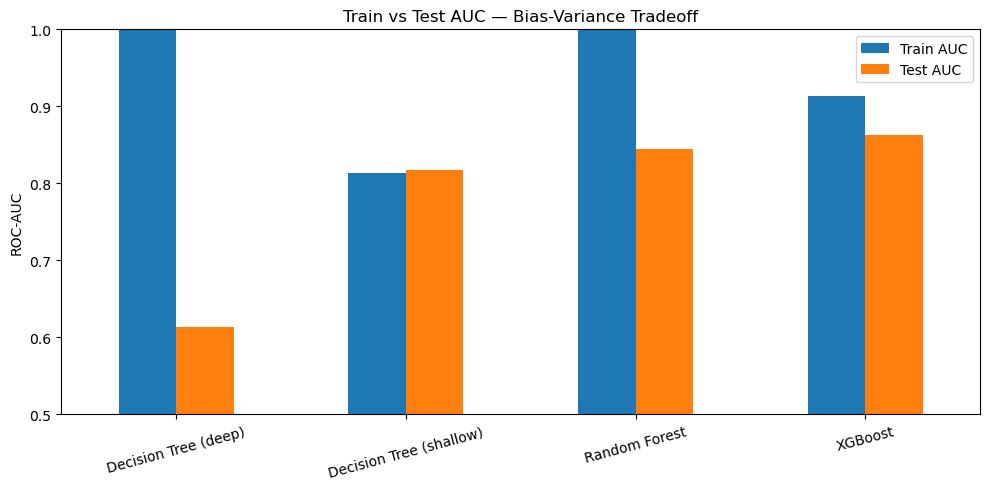

In [16]:
models = {
    'Decision Tree (deep)': DecisionTreeClassifier(max_depth=None, random_state=42),
    'Decision Tree (shallow)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42,
                                   eval_metric='logloss', verbosity=0),
    'MLP (64,32)': MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                 alpha=1e-4, batch_size=256, early_stopping=True,
                                 max_iter=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_sc)[:,1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test_sc)[:,1])
    results[name] = {'Train AUC': train_auc, 'Test AUC': test_auc}
    print(f"{name}: Train AUC={train_auc:.4f}, Test AUC={test_auc:.4f}")

results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(10,5), ylim=(0.5, 1.0))
plt.title('Train vs Test AUC — Bias-Variance Tradeoff')
plt.ylabel('ROC-AUC')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Phase 5 — Evaluation & Threshold Tuning
Accuracy is misleading on imbalanced data. Tune the decision threshold to reflect real lending cost asymmetry.

In [17]:
xgb_model = models['XGBoost']
proba = xgb_model.predict_proba(X_test_sc)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 45)
for t in thresholds:
    preds_t = (proba >= t).astype(int)
    p = precision_score(y_test, preds_t, zero_division=0)
    r = recall_score(y_test, preds_t)
    f = f1_score(y_test, preds_t, zero_division=0)
    print(f"{t:>10.2f} {p:>10.3f} {r:>10.3f} {f:>10.3f}")

 Threshold  Precision     Recall         F1
---------------------------------------------
      0.10      0.279      0.668      0.394
      0.15      0.347      0.571      0.432
      0.20      0.400      0.502      0.445
      0.25      0.438      0.444      0.441
      0.30      0.467      0.382      0.420
      0.35      0.497      0.336      0.401
      0.40      0.520      0.292      0.374
      0.45      0.546      0.252      0.345
      0.50      0.562      0.210      0.306
      0.55      0.584      0.172      0.265
      0.60      0.593      0.128      0.211
      0.65      0.594      0.097      0.167
      0.70      0.637      0.069      0.125
      0.75      0.685      0.050      0.093
      0.80      0.685      0.030      0.057
      0.85      0.643      0.018      0.034


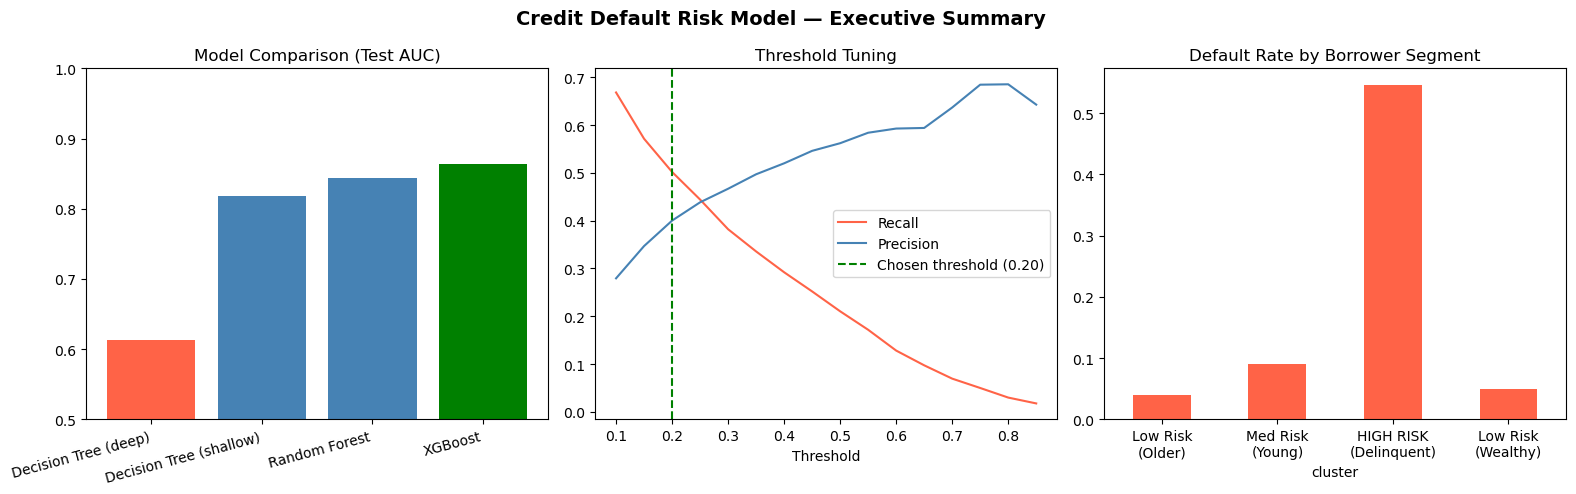

Done!


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names = list(results.keys())
test_aucs = [results[n]['Test AUC'] for n in names]
axes[0].bar(names, test_aucs, color=['tomato','steelblue','steelblue','green','orange'])
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Model Comparison (Test AUC)')
axes[0].set_xticklabels(names, rotation=15, ha='right')

recalls = [recall_score(y_test, (proba>=t).astype(int)) for t in thresholds]
precisions = [precision_score(y_test, (proba>=t).astype(int), zero_division=0) for t in thresholds]
axes[1].plot(thresholds, recalls, 'tomato', label='Recall')
axes[1].plot(thresholds, precisions, 'steelblue', label='Precision')
axes[1].axvline(x=0.20, color='green', linestyle='--', label='Chosen threshold (0.20)')
axes[1].set_title('Threshold Tuning')
axes[1].set_xlabel('Threshold')
axes[1].legend()

cluster_summary['default_rate'].plot(kind='bar', ax=axes[2], color='tomato')
axes[2].set_title('Default Rate by Borrower Segment')
axes[2].set_xticklabels(['Low Risk\n(Older)','Med Risk\n(Young)',
                          'HIGH RISK\n(Delinquent)','Low Risk\n(Wealthy)'], rotation=0)

plt.suptitle('Credit Default Risk Model — Executive Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/paularezzonico/Desktop/credit-default-risk/executive_summary.png', dpi=150)
plt.show()
print("Done!")

## Phase 6 — Cross-Validation & Hyperparameter Tuning
A single train/test split gives one noisy estimate of performance. Here we use **5-fold stratified
cross-validation** for a robust mean ± std AUC on every model, then tune XGBoost with grid search.
The tuned model is retrained on **raw (unscaled) features** — tree ensembles are scale-invariant, and
keeping raw values makes the SHAP / LIME explanations in later phases directly interpretable.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=200))]),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42,
                                 eval_metric='logloss', verbosity=0),
    'MLP (64,32)': Pipeline([('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(64, 32), early_stopping=True,
                              max_iter=80, random_state=42))]),
}

cv_results = {}
print(f"{'Model':<22}{'Mean AUC':>10}{'Std':>9}")
print('-' * 41)
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<22}{scores.mean():>10.4f}{scores.std():>9.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds = [cv_results[n].std() for n in names]
ax.bar(names, means, yerr=stds, capsize=6,
       color=['steelblue', 'seagreen', 'green', 'orange'])
ax.set_ylim(0.70, 0.90)
ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_title('Cross-Validated Model Performance (mean ± std)')
for i, m in enumerate(means):
    ax.text(i, m + 0.006, f'{m:.3f}', ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'learning_rate': [0.1, 0.3],
}
grid = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)
print('Best parameters:', grid.best_params_)
print(f'Best CV AUC:     {grid.best_score_:.4f}')

In [ ]:
# Production model: tuned XGBoost on RAW features (trees are scale-invariant),
# which keeps SHAP / LIME explanations in real borrower units.
xgb_prod = xgb.XGBClassifier(**grid.best_params_, random_state=42,
                             eval_metric='logloss', verbosity=0)
xgb_prod.fit(X_train, y_train)

prod_proba = xgb_prod.predict_proba(X_test)[:, 1]
prod_auc = roc_auc_score(y_test, prod_proba)
print(f'Production XGBoost  |  Test ROC-AUC: {prod_auc:.4f}')

# cluster scaler reused downstream for stress testing and the live app
cluster_scaler = StandardScaler().fit(df[cluster_features])